In [1]:
# 변수의 shape, type, value 확인
def p(var,_name="") :
    if _name != "" : print(f'<<{_name}>>')
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}')

def pst(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}')


# LangGraph Templet 만들기  
  1. 반복되는 **tool / DB / data / node** 생성을 공통화
  2. 새로운 **그래프 구조**에만 집중하도록 설계   

- 공통 구성: 설치·설정, 데이터/툴 팩토리, 상태 스키마, 노드 템플릿, 실행/평가 유틸
- 가변 구성: `패턴(단일Agent · Planner-Executor · Multi-Agent Supervisor)`만 교체

- 과제: 새 노드 추가, 라우팅 규칙 수정, 툴 확장


In [2]:
!pip -q install pydantic faiss-cpu tiktoken sqlite-utils -q
!pip install --prefer-binary langgraph==0.4.0 langchain-openai==0.3.33 langchain-community==0.3.30  -q
!pip install --no-deps "langchain-teddynote==0.3.42" -q
#google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.9/148.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source

In [3]:
import os, sys, time, json, uuid, math, sqlite3, textwrap, typing as t
from dataclasses import dataclass
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal, Annotated

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print("Python:", sys.version)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


# LLM 설정

In [4]:
import os
from google.colab import userdata

# OpenAI API 키는 필요시 설정 (이번 실습에서는 사용하지 않음)
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [5]:
MODEL_NAME = os.environ.get("LLM_MODEL", "gpt-4o-mini")  # 필요 시 변경
EMB_MODEL = os.environ.get("EMB_MODEL", "text-embedding-3-small")

VERBOSE = True
SEED = 7

def get_llm(system:str="당신은 유용한 어시스트 입니다."):
    return ChatOpenAI(model=MODEL_NAME, temperature=0, seed=SEED)

#### Graph 시각화 : 환경에 따라 선택적으로 사용     
1. IPython.display 사용 : 외부 서버(mermaid)를 통해 image 생성 함  
2. langchain_teddynote.graphs

* 1.IPytoh.display

In [6]:
# !pip install nest_asyncio   # Jupyter Notebook에서 비동기 실행을 위해 필요

# from IPython.display import Image, display
# import nest_asyncio

# # 비동기 실행을 위해 필요
# nest_asyncio.apply()

* 2.langchain_teddynote.graphs

In [7]:
from langchain_teddynote.graphs import visualize_graph

## SQLite(seed data) + RAG(FAISS)

In [8]:
### SQLite + 시드데이터 + RAG(FAISS)
DB_PATH = "labs.db"

def init_sqlite(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS faq (
        id INTEGER PRIMARY KEY,
        question TEXT,
        answer   TEXT
    )
    """)
    # 존재 체크 후 시드
    cur.execute("SELECT COUNT(*) FROM faq")
    n = cur.fetchone()[0]
    if n == 0:
        cur.executemany(
            "INSERT INTO faq(id,question,answer) VALUES(?,?,?)",
            [
              (1, "반도체 식각 공정이란?", "식각은 PR 패턴을 마스크로 하여 박막을 제거하는 공정이다."),
              (2, "LangGraph 용도?", "상태 기반 에이전트 워크플로를 그래프로 구성한다."),
              (3, "GNN 장점?", "그래프 구조 데이터를 학습해 관계 중심 문제에 강하다."),
            ]
        )
    conn.commit()
    conn.close()

def sql_query(q:str, params:tuple=()):
    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()
    cur.execute(q, params)
    rows = cur.fetchall()
    cols = [d[0] for d in cur.description] if cur.description else []
    conn.close()
    return cols, rows

init_sqlite()

# 간단한 RAG용 벡터 스토어
def build_vectorstore(texts:list[str]):
    embeddings = OpenAIEmbeddings(model=EMB_MODEL)
    metadatas = [{"i":i} for i,_ in enumerate(texts)]
    return FAISS.from_texts(texts=texts, embedding=embeddings, metadatas=metadatas)

RAG_TEXTS = [
    "LangGraph는 상태(State)를 중심으로 LLM 호출과 툴 실행을 오케스트레이션한다.",
    "Planner-Executor 패턴은 계획 수립 노드와 실행 노드를 분리한다.",
    "Supervisor는 여러 전문가 에이전트를 라우팅하고 종료 조건을 관리한다.",
]
VS = build_vectorstore(RAG_TEXTS)

## Tools

In [9]:
### Tool Factory
@tool
def sql_faq(query: str) -> str:
    """
    FAQ SQLite를 조회한다. 예: SELECT * FROM faq WHERE question LIKE '%LangGraph%'
    """
    try:
        cols, rows = sql_query(query)
        if not rows:
            return "no rows"
        out = [dict(zip(cols, r)) for r in rows]
        return json.dumps(out, ensure_ascii=False)
    except Exception as e:
        return f"sql error: {e}"

@tool
def vector_search(question: str, k: int = 2) -> str:
    """
    간단한 RAG 질의. 코사인 근접 Top-k를 반환.
    """
    try:
        docs = VS.similarity_search(question, k=k)
        return json.dumps([{"text": d.page_content, "meta": d.metadata} for d in docs], ensure_ascii=False)
    except Exception as e:
        return f"rag error: {e}"

@tool
def calc(expr: str) -> str:
    """
    간단 계산기. eval 사용 주의. 교육용으로 제한적으로 사용.
    예: 3*(2+5)
    """
    try:
        # 간단 방어: 허용 문자만
        if not all(c in "0123456789+-*/(). " for c in expr):
            return "invalid expr"
        return str(eval(expr))
    except Exception as e:
        return f"calc error: {e}"

def get_tools(names: list[str] = None):
    catalog = {
        "sql_faq": sql_faq,
        "vector_search": vector_search,
        "calc": calc,
    }
    return [catalog[n] for n in (names or list(catalog.keys()))]


## Agent State  


In [10]:
### Agent State
class AgentState(TypedDict, total=False):
    messages: list  # LangChain message objects
    route: str      # 다음 노드 이름
    plan: str       # 계획 텍스트
    result: str     # 마지막 결과
    meta: dict      # 기타 메타데이터

def add_message(state: AgentState, msg):
    state = dict(state)
    state["messages"] = (state.get("messages") or []) + [msg]
    return state

# Node tamplets : LLM, tool call, router, supervisor  


In [11]:
### Node tamplets : LLM, tool call, router, supervisor

from langchain_core.messages import SystemMessage

def make_llm_node(system: str, name: str, tools=None):
    llm = get_llm()
    if tools:
        llm = llm.bind_tools(tools)

    sys_msg = SystemMessage(content=system)

    def _node(state: AgentState):
        msgs = (state.get("messages") or [])
        resp = llm.invoke([sys_msg] + msgs)
        st = add_message(state, resp)
        return st

    _node.__name__ = name
    return _node

def make_tool_node(tool_func, name: str):
    def _node(state: AgentState):
        # 마지막 AIMessage 내 tool_calls 실행
        msgs = state.get("messages") or []
        ai = [m for m in msgs if isinstance(m, AIMessage)]
        if not ai:
            return state
        last = ai[-1]
        new_state = dict(state)
        for tc in (last.tool_calls or []):
            if tc["name"] == tool_func.name:
                args = tc.get("args") or {}
                out = tool_func.invoke(args)
                tm = ToolMessage(tool_call_id=tc["id"], content=str(out), name=tool_func.name)
                new_state = add_message(new_state, tm)
        return new_state
    _node.__name__ = name
    return _node

def router_node(routes: dict[str, str], default: str):
    """AIMessage의 내용을 기준으로 간단 키워드 라우팅"""
    def _node(state: AgentState):
        msgs = state.get("messages") or []
        text = ""
        for m in reversed(msgs):
            if isinstance(m, HumanMessage):
                text = m.content or ""
                break
        for k, v in routes.items():
            if k.lower() in text.lower():
                state["route"] = v
                return state
        state["route"] = default
        return state
    return _node

def supervisor_node(agents: list[str], max_turns: int = 4):
    """간단 다중 에이전트 수퍼바이저. 종료 조건: 'done' 키워드."""
    def _node(state: AgentState):
        msgs = state.get("messages") or []
        turns = state.get("meta", {}).get("turns", 0)
        if turns >= max_turns:
            state["route"] = "final"
            return state
        # 가장 최근 사용자 메시지 읽어 키워드로 라우팅
        text = ""
        for m in reversed(msgs):
            if isinstance(m, HumanMessage):
                text = m.content or ""
                break
        if "done" in text.lower() or "완료" in text:
            state["route"] = "final"
        elif "sql" in text.lower() or "faq" in text.lower():
            state["route"] = agents[0]
        elif "rag" in text.lower() or "검색" in text:
            state["route"] = agents[1] if len(agents) > 1 else agents[0]
        elif "calc" in text.lower() or "계산" in text:
            state["route"] = agents[2] if len(agents) > 2 else agents[0]
        else:
            state["route"] = agents[0]
        meta = dict(state.get("meta") or {})
        meta["turns"] = turns + 1
        state["meta"] = meta
        return state
    return _node


## Run utils  


In [12]:
### 실행 유틸
from typing import Optional

# 체크포인터 사용 시 thread_id 필요
def run_graph(app, user_text: str, metadata: dict | None = None, thread_id: Optional[str] = None):
    state = {"messages": [HumanMessage(content=user_text)], "meta": metadata or {}}
    if thread_id is None:
        thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}
    return app.invoke(state, config=config)

# LangGraph 시각화 옵션 래퍼
def compile_and_viz(builder_fn, *, visualize: bool = False):
    app = builder_fn()
    if visualize:
        visualize_graph(app)
    return app

def print_dialog(state: dict):
    msgs = state.get("messages") or []
    for m in msgs:
        role = m.type
        if role == "system": continue
        print(f"[{role.upper()}] {getattr(m,'name',None) or ''}")
        print((m.content if isinstance(m.content,str) else str(m.content))[:2000])
        print("-"*40)

# Singel Agent

In [13]:
def build_single_agent():
    tools = get_tools(["vector_search"])
    sys_prompt = "주어진 질문에 대해 필요시 vector_search 툴을 호출해 근거를 찾아 답하라."
    llm_node = make_llm_node(sys_prompt, "agent", tools=tools)
    tool_node = make_tool_node(tools[0], "vector_tool")

    g = StateGraph(AgentState)
    g.add_node("agent", llm_node)
    g.add_node("vector_tool", tool_node)

    # ReAct 스타일: 도구 호출이 있으면 툴 실행 후 다시 agent
    def decide(state: AgentState):
        msgs = state.get("messages") or []
        ai = [m for m in msgs if isinstance(m, AIMessage)]
        if ai and ai[-1].tool_calls:
            return "vector_tool"
        return "final"

    g.add_edge(START, "agent")
    g.add_conditional_edges("agent", decide, {"vector_tool": "vector_tool", "final": END})
    g.add_edge("vector_tool", "agent")
    memory = MemorySaver()
    return g.compile(checkpointer=memory)


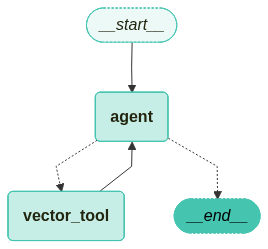

[HUMAN] 
LangGraph는 무엇인가? 필요시 rag로 근거를 찾아라.
----------------------------------------
[AI] 

----------------------------------------
[TOOL] vector_search
[{"text": "LangGraph는 상태(State)를 중심으로 LLM 호출과 툴 실행을 오케스트레이션한다.", "meta": {"i": 0}}, {"text": "Planner-Executor 패턴은 계획 수립 노드와 실행 노드를 분리한다.", "meta": {"i": 1}}]
----------------------------------------
[AI] 
LangGraph는 상태(State)를 중심으로 LLM(대형 언어 모델) 호출과 툴 실행을 오케스트레이션하는 시스템입니다. 이 시스템은 Planner-Executor 패턴을 사용하여 계획 수립 노드와 실행 노드를 분리합니다. 이를 통해 보다 효율적인 작업 수행이 가능해집니다.
----------------------------------------


In [14]:
agent = build_single_agent
app = compile_and_viz(agent, visualize=True)
out = run_graph(app, "LangGraph는 무엇인가? 필요시 rag로 근거를 찾아라.")
print_dialog(out)

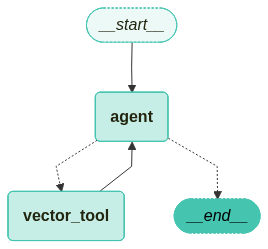

# planner_executor Agent

In [15]:
def build_planner_executor():
    tools = get_tools(["sql_faq", "vector_search", "calc"])
    planner = make_llm_node("너는 계획 수립자다. 사용자 목표를 달성하기 위한 단계 계획을 생성하라.", "planner")
    executor = make_llm_node("너는 실행자다. 필요한 경우 등록된 툴을 호출하여 계획을 수행하라.", "executor", tools=tools)
    sql_node = make_tool_node(tools[0], "sql_tool")
    rag_node = make_tool_node(tools[1], "rag_tool")
    calc_node = make_tool_node(tools[2], "calc_tool")

    g = StateGraph(AgentState)
    g.add_node("planner", planner)
    g.add_node("executor", executor)
    g.add_node("sql_tool", sql_node)
    g.add_node("rag_tool", rag_node)
    g.add_node("calc_tool", calc_node)

    def route_from_executor(state: AgentState):
        msgs = state.get("messages") or []
        ai = [m for m in msgs if isinstance(m, AIMessage)]
        if ai and ai[-1].tool_calls:
            calls = [c["name"] for c in ai[-1].tool_calls]
            if "sql_faq" in calls: return "sql_tool"
            if "vector_search" in calls: return "rag_tool"
            if "calc" in calls: return "calc_tool"
        return "final"

    g.add_edge(START, "planner")
    g.add_edge("planner", "executor")
    g.add_conditional_edges("executor", route_from_executor, {
        "sql_tool": "sql_tool",
        "rag_tool": "rag_tool",
        "calc_tool": "calc_tool",
        "final": END
    })
    g.add_edge("sql_tool", "executor")
    g.add_edge("rag_tool", "executor")
    g.add_edge("calc_tool", "executor")

    memory = MemorySaver()
    return g.compile(checkpointer=memory)

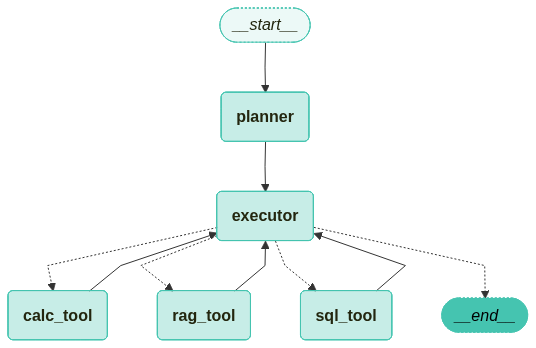

[HUMAN] 
LangGraph는 무엇인가? 필요시 rag로 근거를 찾아라.
----------------------------------------
[AI] 
LangGraph는 자연어 처리(NLP)와 그래프 기반 데이터 구조를 결합한 시스템으로, 언어 모델이 텍스트 데이터를 이해하고 처리하는 데 도움을 주는 도구입니다. LangGraph는 언어의 의미와 구조를 그래프 형태로 표현하여, 다양한 언어적 관계를 시각화하고 분석할 수 있게 합니다. 이를 통해 언어 모델은 더 나은 이해와 응답 생성을 할 수 있습니다.

LangGraph의 주요 기능은 다음과 같습니다:

1. **구조적 표현**: 텍스트의 의미를 그래프 형태로 변환하여, 단어와 구문 간의 관계를 명확히 합니다.
2. **정보 검색**: 그래프 구조를 활용하여 관련 정보를 더 쉽게 검색하고 추출할 수 있습니다.
3. **지식 통합**: 다양한 출처의 정보를 통합하여, 더 풍부한 언어 모델을 구축할 수 있습니다.

이와 같은 기능들은 LangGraph가 자연어 처리 분야에서 유용하게 사용될 수 있도록 합니다.

필요한 경우, RAG(정보 검색 기반 생성 모델)를 사용하여 LangGraph에 대한 더 구체적인 정보를 찾을 수 있습니다. RAG는 질문에 대한 답변을 생성하기 위해 외부 데이터베이스에서 정보를 검색하고, 이를 바탕으로 응답을 생성하는 방식입니다. 이를 통해 LangGraph에 대한 최신 정보나 연구 결과를 확인할 수 있습니다.
----------------------------------------
[AI] 

----------------------------------------
[TOOL] vector_search
[{"text": "LangGraph는 상태(State)를 중심으로 LLM 호출과 툴 실행을 오케스트레이션한다.", "meta": {"i": 0}}, {"text": "Planner-Executor 패턴은 계획 수립 노드와 실행 노드를 분리한다.", "meta": {"i":

In [16]:
# "planexec":
agent = build_planner_executor
app = compile_and_viz(agent, visualize=True)
out = run_graph(app, "LangGraph는 무엇인가? 필요시 rag로 근거를 찾아라.")
print_dialog(out)

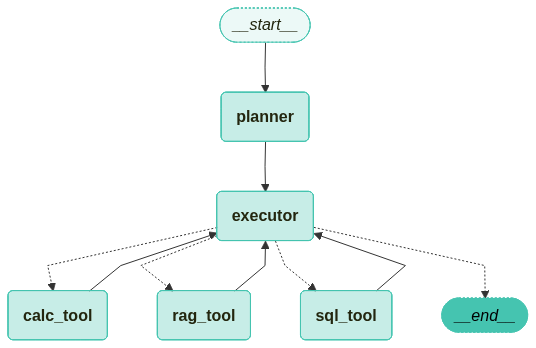

# Multi Agent Supervisor

In [17]:
def build_multi_agent_supervisor():
    tools = get_tools(["sql_faq", "vector_search", "calc"])
    # 전문가 노드들
    sql_agent = make_llm_node("너는 SQL 전문가다. 필요시 sql_faq를 호출해 근거를 제시하라.", "sql_agent", tools=[tools[0]])
    rag_agent = make_llm_node("너는 RAG 전문가다. vector_search로 근거 문장을 찾아라.", "rag_agent", tools=[tools[1]])
    calc_agent = make_llm_node("너는 계산 전문가다. calc를 사용해 계산을 수행하라.", "calc_agent", tools=[tools[2]])
    # 툴 노드
    sql_tool = make_tool_node(tools[0], "sql_tool")
    rag_tool = make_tool_node(tools[1], "rag_tool")
    calc_tool = make_tool_node(tools[2], "calc_tool")
    # 감독
    sup = supervisor_node(["sql_agent", "rag_agent", "calc_agent"], max_turns=4)

    g = StateGraph(AgentState)
    for name, fn in [
        ("supervisor", sup),
        ("sql_agent", sql_agent), ("rag_agent", rag_agent), ("calc_agent", calc_agent),
        ("sql_tool", sql_tool), ("rag_tool", rag_tool), ("calc_tool", calc_tool)
    ]:
        g.add_node(name, fn)

    def route_after_agent(state: AgentState):
        msgs = state.get("messages") or []
        ai = [m for m in msgs if isinstance(m, AIMessage)]
        if ai and ai[-1].tool_calls:
            calls = [c["name"] for c in ai[-1].tool_calls]
            if "sql_faq" in calls: return "sql_tool"
            if "vector_search" in calls: return "rag_tool"
            if "calc" in calls: return "calc_tool"
        return "supervisor"

    g.add_edge(START, "supervisor")
    # supervisor -> agent
    g.add_conditional_edges("supervisor",
        lambda s: s.get("route","sql_agent"),
        {"sql_agent":"sql_agent", "rag_agent":"rag_agent", "calc_agent":"calc_agent", "final": END}
    )
    # 각 agent -> tool or back to supervisor
    for ag, toolname in [("sql_agent","sql_tool"), ("rag_agent","rag_tool"), ("calc_agent","calc_tool")]:
        g.add_conditional_edges(ag, route_after_agent, {
            "sql_tool": "sql_tool", "rag_tool": "rag_tool", "calc_tool": "calc_tool", "supervisor": "supervisor"
        })
    # tool -> supervisor
    for tname in ["sql_tool","rag_tool","calc_tool"]:
        g.add_edge(tname, "supervisor")

    memory = MemorySaver()
    return g.compile(checkpointer=memory)


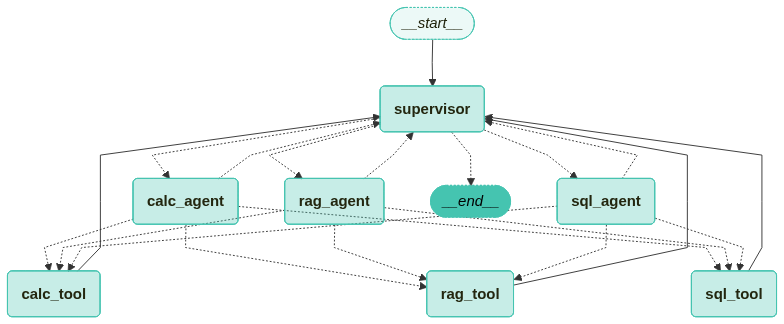

[HUMAN] 
LangGraph는 무엇인가? 필요시 rag로 근거를 찾아라.
----------------------------------------
[AI] 

----------------------------------------
[TOOL] vector_search
[{"text": "LangGraph는 상태(State)를 중심으로 LLM 호출과 툴 실행을 오케스트레이션한다.", "meta": {"i": 0}}, {"text": "Planner-Executor 패턴은 계획 수립 노드와 실행 노드를 분리한다.", "meta": {"i": 1}}]
----------------------------------------
[AI] 
LangGraph는 상태(State)를 중심으로 LLM 호출과 툴 실행을 오케스트레이션하는 시스템입니다. 이 시스템은 Planner-Executor 패턴을 사용하여 계획 수립 노드와 실행 노드를 분리합니다.
----------------------------------------
[AI] 

----------------------------------------
[TOOL] vector_search
[{"text": "LangGraph는 상태(State)를 중심으로 LLM 호출과 툴 실행을 오케스트레이션한다.", "meta": {"i": 0}}, {"text": "Planner-Executor 패턴은 계획 수립 노드와 실행 노드를 분리한다.", "meta": {"i": 1}}]
----------------------------------------
[AI] 
LangGraph의 기능과 특징은 다음과 같습니다:

1. **상태(State) 중심 오케스트레이션**: LangGraph는 상태를 중심으로 LLM 호출과 툴 실행을 오케스트레이션합니다.
2. **Planner-Executor 패턴**: 이 시스템은 계획 수립 노드와 실행 노드를 분리하는 Planner-Executor 패턴을 사용합니다. 

이러한 구조는 복잡한 작업을 

In [ ]:
# "multi":
agent = build_multi_agent_supervisor
app = compile_and_viz(agent, visualize=True)
out = run_graph(app, "LangGraph는 무엇인가? 필요시 rag로 근거를 찾아라.")
print_dialog(out)

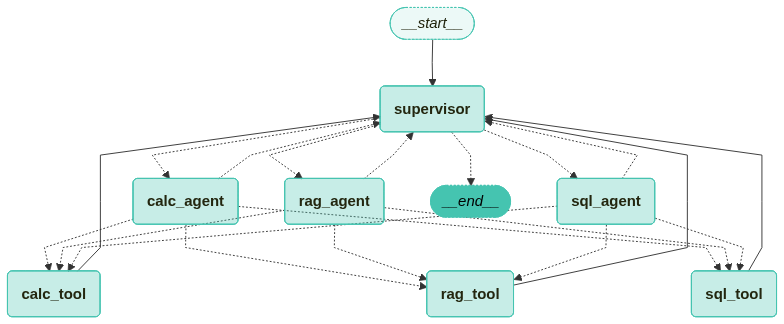

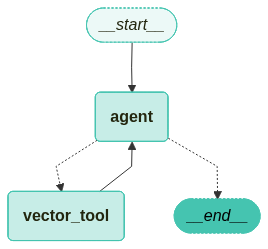

[
  {
    "q": "식각 공정 설명해줘. SQL로 근거를 찾아.",
    "secs": 10.328,
    "tools": [
      "vector_search",
      "vector_search"
    ]
  },
  {
    "q": "LangGraph의 핵심 개념을 설명해줘. 필요한 경우 rag 검색 사용.",
    "secs": 6.052,
    "tools": [
      "vector_search"
    ]
  },
  {
    "q": "3*(2+7) 값을 계산해줘. calc 사용.",
    "secs": 4.673,
    "tools": [
      "vector_search"
    ]
  },
  {
    "q": "끝. 완료.",
    "secs": 0.956,
    "tools": []
  }
]


In [ ]:
# 간단 배치 평가: 질문 세트와 사용 툴 로그
QUESTS = [
    "식각 공정 설명해줘. SQL로 근거를 찾아.",
    "LangGraph의 핵심 개념을 설명해줘. 필요한 경우 rag 검색 사용.",
    "3*(2+7) 값을 계산해줘. calc 사용.",
    "끝. 완료."
]

def tool_usage(messages) -> list[str]:
    used = []
    for m in messages:
        if isinstance(m, AIMessage) and m.tool_calls:
            used += [c["name"] for c in m.tool_calls]
    return used


agent = build_single_agent
app = compile_and_viz(agent, visualize=True)

logs = []
for q in QUESTS:
    t0 = time.time()
    st = run_graph(app, q, metadata={"qid": q})
    dt = time.time() - t0
    used = tool_usage(st.get("messages") or [])
    logs.append({"q": q, "secs": round(dt,3), "tools": used})

print(json.dumps(logs, ensure_ascii=False, indent=2))

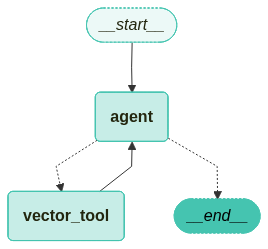

# 실습 과제
1. `router_node`를 키워드 대신 LLM 판단으로 교체해보자.
2. `get_tools()`에 HTTP API 호출 툴을 추가해보자.
3. `build_planner_executor()`에서 계획의 단계별 완료 체크리스트를 상태에 저장하자.
4. `build_multi_agent_supervisor()`의 종료 규칙을 "품질 점수 ≥ 임계값"으로 확장해 보자.
5. 동일한 툴을 노드 간 공유할 때, 공통 캐시 계층을 넣어 호출 수를 줄여보자.


### HTTP API 호출 툴 추가

In [18]:
import requests

@tool
def http_get(url: str, params_json: str = "{}", timeout: int = 10) -> str:
    """
    간단 HTTP GET 툴.
    - url: 호출할 URL
    - params_json: JSON 문자열(예: '{"q":"langgraph"}')
    교육/실습용. 외부 네트워크 차단 환경에서는 실패할 수 있음.
    """
    try:
        params = json.loads(params_json) if params_json else {}
    except Exception as e:
        return f"param error: {e}"
    try:
        r = requests.get(url, params=params, timeout=timeout)
        return json.dumps({
            "status": r.status_code,
            "url": r.url,
            "text": r.text[:2000]   # 표시 길이 제한
        }, ensure_ascii=False)
    except Exception as e:
        return f"http error: {e}"

In [19]:
# 상태 스키마
class AgentState(TypedDict, total=False):
    messages: list               # LangChain message objects
    route: str                   # 다음 노드 이름
    plan: str                    # 계획 텍스트
    result: str                  # 마지막 결과
    meta: dict                   # 메타데이터
    checklist: list[dict]        # [{step:int, text:str, status:'todo'|'done'}]
    quality: float               # 품질 점수(0~1)


In [20]:
def get_tools(names: list[str] | None = None):
    catalog = {
        "http_get":       http_get,
        "sql_faq":        sql_faq,
        "vector_search":  vector_search,
        "calc":           calc,
    }
    return [catalog[n] for n in (names or list(catalog.keys()))]

# Planner-Executor with checklist

In [21]:
import re

# Planner-Executor with checklist
def parse_checklist(text: str) -> list[dict]:
    # "1. ...", "2) ..." 형태를 단계 리스트로 파싱
    items = []
    for m in re.finditer(r"(\d+)[\.\)]\s*(.+)", text):
        idx = int(m.group(1))
        desc = m.group(2).strip()
        items.append({"step": idx, "text": desc, "status": "todo"})
    # 빈 경우 한 단계라도 생성
    if not items and text.strip():
        items = [{"step": 1, "text": text.strip(), "status": "todo"}]
    return items

def mark_next_done(checklist: list[dict]) -> list[dict]:
    for it in checklist:
        if it.get("status") != "done":
            it["status"] = "done"
            break
    return checklist

def all_done(checklist: list[dict]) -> bool:
    return checklist and all(it.get("status") == "done" for it in checklist)

def build_planner_executor_solved():
    tools = get_tools(["sql_faq", "vector_search", "calc", "http_get"])
    planner = make_llm_node("너는 계획 수립자다. 사용자 목표를 달성하기 위한 단계 계획을 번호 목록으로 제공하라.","planner")
    executor = make_llm_node("너는 실행자다. 계획을 한 단계씩 수행한다. 필요 시 툴을 호출한다.","executor", tools=tools)
    sql_node  = make_tool_node(tools[0], "sql_tool")
    rag_node  = make_tool_node(tools[1], "rag_tool")
    calc_node = make_tool_node(tools[2], "calc_tool")
    http_node = make_tool_node(tools[3], "http_tool")

    g = StateGraph(AgentState)
    g.add_node("planner", planner)
    g.add_node("executor", executor)
    g.add_node("sql_tool", sql_node)
    g.add_node("rag_tool", rag_node)
    g.add_node("calc_tool", calc_node)
    g.add_node("http_tool", http_node)

    # 계획 수립 후 체크리스트 저장
    def after_planner(state: AgentState):
        msgs = state.get("messages") or []
        ai = [m for m in msgs if isinstance(m, AIMessage)]
        plan_text = ai[-1].content if ai else ""
        state["plan"] = plan_text if isinstance(plan_text,str) else str(plan_text)
        state["checklist"] = parse_checklist(state["plan"])
        return "executor"

    # 실행자 라우팅: 툴콜 → 해당 툴, 아니면 체크리스트 갱신 후 종료 여부 판단
    def route_from_executor(state: AgentState):
        msgs = state.get("messages") or []
        ai = [m for m in msgs if isinstance(m, AIMessage)]
        if ai and ai[-1].tool_calls:
            calls = [c["name"] for c in ai[-1].tool_calls]
            if "sql_faq" in calls:   return "sql_tool"
            if "vector_search" in calls: return "rag_tool"
            if "calc" in calls:      return "calc_tool"
            if "http_get" in calls:  return "http_tool"
        # 툴 호출 없으면 한 단계 완료 처리
        state["checklist"] = mark_next_done(state.get("checklist") or [])
        if all_done(state["checklist"]):
            return "final"
        return "executor"

    g.add_edge(START, "planner")
    g.add_conditional_edges("planner", after_planner, {"executor": "executor"})
    g.add_conditional_edges("executor", route_from_executor, {
        "sql_tool": "sql_tool",
        "rag_tool": "rag_tool",
        "calc_tool": "calc_tool",
        "http_tool": "http_tool",
        "executor": "executor",
        "final": END
    })
    # 각 툴 실행 후 다시 executor
    for n in ["sql_tool","rag_tool","calc_tool","http_tool"]:
        g.add_edge(n, "executor")

    memory = MemorySaver()
    return g.compile(checkpointer=memory)


In [ ]:
agent = build_planner_executor_solved
app = compile_and_viz(agent, visualize=True)

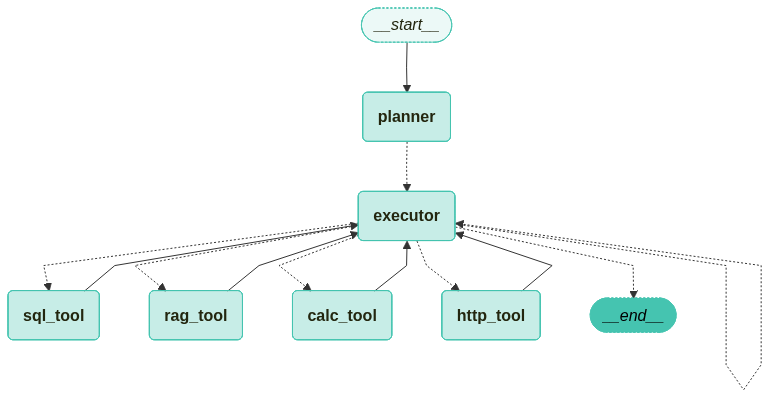

In [ ]:
st = run_graph(app, "LangGraph 핵심 개념을 설명하고, 관련 근거를 하나 찾은 뒤 결과를 요약하라.")
print_dialog(st)
print("Checklist:", st.get("checklist"))

# Supervisor with quality threshold

In [24]:
def make_quality_judge_node(threshold: float = 0.7):
    sys_prompt = (
        "너는 품질 평가자다. 대화의 최신 응답 품질을 0.0~1.0 사이로 평가한다. "
        + "정확성, 근거, 완결성을 고려한다. 오직 JSON으로만 출력: {\"quality\": <float>}"
    )
    llm = get_llm(sys_prompt)

    def _node(state: AgentState):
        msgs = state.get("messages") or []
        # 최근 AI 응답만 넣어 심플 평가
        ai = [m for m in msgs if isinstance(m, AIMessage)]
        if not ai:
            state["quality"] = 0.0
            return state
        last_ai = ai[-1]
        resp = llm.invoke([HumanMessage(content=str(last_ai.content)[:2000])])
        try:
            j = json.loads(resp.content if isinstance(resp.content,str) else str(resp.content))
            q = float(j.get("quality", 0.0))
        except Exception:
            q = 0.0
        state["quality"] = q
        return add_message(state, resp)
    return _node

In [25]:
## LLM 기반 라우터 노드
# 시스템 프롬프트: routes 키만 택해 JSON으로 반환하도록 강제
import json

def make_llm_router_node(routes: list[str], default: str):
    sys_prompt = (
        "당신은 라우터다. 사용자의 최신 요청을 읽고 다음 중 하나를 선택하라: "
        + ", ".join(routes)
        + ".\n"
        + "출력은 JSON 한 줄만 허용한다. 형식: {\"route\": \"<선택>\"}\n"
        + f"허용되지 않은 값이면 \"route\":\"{default}\" 로 설정하라."
    )
    llm = get_llm(sys_prompt)

    def _node(state: AgentState):
        # 최신 Human 메시지 하나만 전달
        msgs = state.get("messages") or []
        last_human = None
        for m in reversed(msgs):
            if isinstance(m, HumanMessage):
                last_human = m
                break
        if last_human is None:
            state["route"] = default
            return state
        resp = llm.invoke([last_human])
        text = resp.content if isinstance(resp.content, str) else str(resp.content)
        try:
            j = json.loads(text.strip())
            route = j.get("route", default)
            if route not in routes:
                route = default
        except Exception:
            route = default
        state["route"] = route
        return add_message(state, resp)
    return _node


In [26]:
def build_multi_agent_supervisor_solved(threshold: float = 0.7):
    tools = get_tools(["sql_faq", "vector_search", "calc", "http_get"])

    sql_agent  = make_llm_node("너는 SQL 전문가다. 필요시 sql_faq를 호출해 근거를 제시하라.", "sql_agent", tools=[tools[0]])
    rag_agent  = make_llm_node("너는 RAG 전문가다. vector_search로 근거 문장을 찾아라.", "rag_agent", tools=[tools[1]])
    calc_agent = make_llm_node("너는 계산 전문가다. calc를 사용해 계산을 수행하라.", "calc_agent", tools=[tools[2]])
    web_agent  = make_llm_node("너는 웹 조회 전문가다. http_get을 사용해 간단한 HTTP 요청을 수행하라.", "web_agent", tools=[tools[3]])

    sql_tool  = make_tool_node(tools[0], "sql_tool")
    rag_tool  = make_tool_node(tools[1], "rag_tool")
    calc_tool = make_tool_node(tools[2], "calc_tool")
    http_tool = make_tool_node(tools[3], "http_tool")

    # 1) 라우터를 LLM 판별로 교체
    router = make_llm_router_node(
        routes=["sql_agent","rag_agent","calc_agent","web_agent","final"],
        default="sql_agent"
    )
    judge = make_quality_judge_node(threshold=threshold)

    g = StateGraph(AgentState)
    for name, fn in [
        ("router", router),
        ("judge",  judge),
        ("sql_agent", sql_agent), ("rag_agent", rag_agent),
        ("calc_agent", calc_agent), ("web_agent", web_agent),
        ("sql_tool", sql_tool), ("rag_tool", rag_tool),
        ("calc_tool", calc_tool), ("http_tool", http_tool)
    ]:
        g.add_node(name, fn)

    # 시작 → 라우터
    g.add_edge(START, "router")

    # 에이전트 → 툴 혹은 심사 → 라우터/종료
    def route_after_agent(state: AgentState):
        msgs = state.get("messages") or []
        ai = [m for m in msgs if isinstance(m, AIMessage)]
        if ai and ai[-1].tool_calls:
            calls = [c["name"] for c in ai[-1].tool_calls]
            if "sql_faq" in calls:      return "sql_tool"
            if "vector_search" in calls:return "rag_tool"
            if "calc" in calls:         return "calc_tool"
            if "http_get" in calls:     return "http_tool"
        return "judge"

    for ag in ["sql_agent","rag_agent","calc_agent","web_agent"]:
        g.add_conditional_edges(ag, route_after_agent, {
            "sql_tool":"sql_tool","rag_tool":"rag_tool","calc_tool":"calc_tool","http_tool":"http_tool","judge":"judge"
        })

    # 툴 → 심사
    for tname in ["sql_tool","rag_tool","calc_tool","http_tool"]:
        g.add_edge(tname, "judge")

    # 심사 → 품질 기준
    def after_judge(state: AgentState):
        q = float(state.get("quality") or 0.0)
        return "final" if q >= threshold else "router"

    g.add_conditional_edges("judge", after_judge, {"final": END, "router": "router"})

    memory = MemorySaver()
    return g.compile(checkpointer=memory)

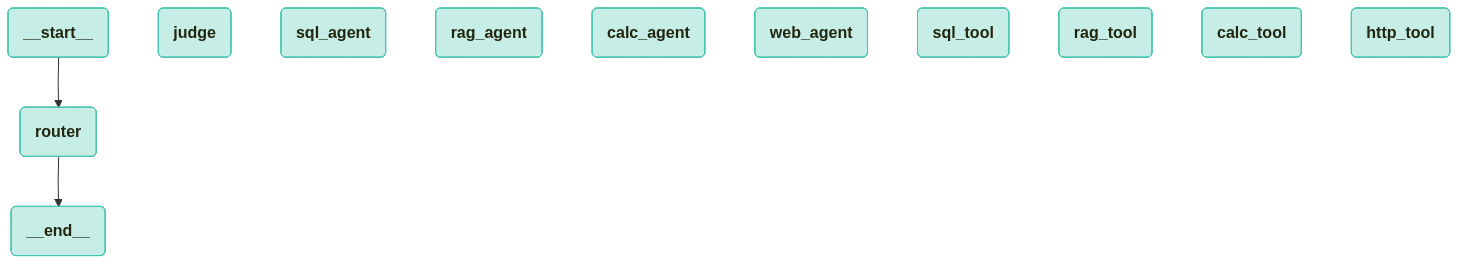

In [27]:
agent_builder_supervisor = lambda: build_multi_agent_supervisor_solved(threshold=0.65)
app_supervisor = compile_and_viz(agent_builder_supervisor, visualize=True)

In [ ]:
st_supervisor = run_graph(app_supervisor, "LangGraph가 무엇인지 설명하고 필요하면 RAG 검색으로 근거를 찾아라.")
print_dialog(st_supervisor)
print("Quality:", st_supervisor.get("quality"))

[HUMAN] 
LangGraph가 무엇인지 설명하고 필요하면 RAG 검색으로 근거를 찾아라.
----------------------------------------
[AI] 
LangGraph는 자연어 처리(NLP)와 그래프 데이터베이스를 결합한 개념으로, 언어 모델과 그래프 구조를 활용하여 정보를 효율적으로 저장하고 검색하는 방법을 제공합니다. 이 시스템은 언어 모델이 텍스트 데이터를 이해하고, 그래프 구조가 데이터 간의 관계를 명확하게 표현할 수 있도록 합니다. LangGraph는 주로 지식 그래프, 정보 검색, 질문 응답 시스템 등에서 활용될 수 있습니다.

LangGraph의 주요 특징은 다음과 같습니다:

1. **정보 구조화**: 텍스트 데이터를 그래프 형태로 구조화하여, 데이터 간의 관계를 명확히 할 수 있습니다.
2. **효율적인 검색**: 그래프 구조를 통해 관련 정보를 빠르게 검색할 수 있습니다.
3. **지식 통합**: 다양한 출처의 정보를 통합하여 더 풍부한 지식을 제공할 수 있습니다.

RAG( Retrieval-Augmented Generation) 검색은 LangGraph와 같은 시스템에서 정보를 검색하고 생성하는 데 유용한 방법입니다. RAG는 외부 데이터베이스에서 정보를 검색한 후, 이를 바탕으로 자연어로 응답을 생성하는 방식입니다. 이 접근법은 정보의 정확성을 높이고, 더 풍부한 응답을 생성하는 데 기여합니다.

이와 관련된 구체적인 자료나 연구 결과를 찾기 위해 RAG 검색을 활용할 수 있습니다. RAG는 특히 대규모 언어 모델과 결합하여, 정보 검색과 생성의 효율성을 극대화하는 데 도움을 줍니다.
----------------------------------------
Quality: None


# single_agent_with_llm_router

In [ ]:
## LLM 기반 라우터 노드
# 시스템 프롬프트: routes 키만 택해 JSON으로 반환하도록 강제
import json

def make_llm_router_node(routes: list[str], default: str):
    sys_prompt = (
        "당신은 라우터다. 사용자의 최신 요청을 읽고 다음 중 하나를 선택하라: "
        + ", ".join(routes)
        + ".\n"
        + "출력은 JSON 한 줄만 허용한다. 형식: {\"route\": \"<선택>\"}\n"
        + f"허용되지 않은 값이면 \"route\":\"{default}\" 로 설정하라."
    )
    llm = get_llm(sys_prompt)

    def _node(state: AgentState):
        # 최신 Human 메시지 하나만 전달
        msgs = state.get("messages") or []
        last_human = None
        for m in reversed(msgs):
            if isinstance(m, HumanMessage):
                last_human = m
                break
        if last_human is None:
            state["route"] = default
            return state
        resp = llm.invoke([last_human])
        text = resp.content if isinstance(resp.content, str) else str(resp.content)
        try:
            j = json.loads(text.strip())
            route = j.get("route", default)
            if route not in routes:
                route = default
        except Exception:
            route = default
        state["route"] = route
        return add_message(state, resp)
    return _node


In [ ]:
def build_single_agent_with_llm_router():
    tools = get_tools(["vector_search"])
    agent = make_llm_node("질문에 답하라. 필요시 vector_search를 호출하라.", "agent", tools=tools)
    tooln = make_tool_node(tools[0], "vector_tool")

    router = make_llm_router_node(["agent","final"], default="agent")

    g = StateGraph(AgentState)
    g.add_node("router", router)
    g.add_node("agent", agent)
    g.add_node("vector_tool", tooln)

    def decide(state: AgentState):
        msgs = state.get("messages") or []
        ai = [m for m in msgs if isinstance(m, AIMessage)]
        if ai and ai[-1].tool_calls:
            return "vector_tool"
        return "router"

    g.add_edge(START, "router")
    g.add_conditional_edges("agent", decide, {"vector_tool":"vector_tool","router":"router"})
    g.add_edge("vector_tool", "agent")

    memory = MemorySaver()
    return g.compile(checkpointer=memory)

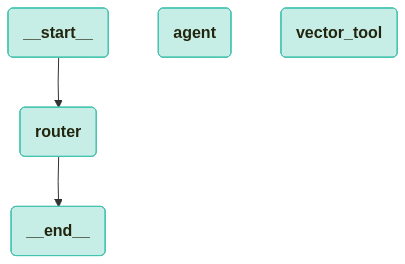

In [ ]:
agent_builder_single = build_single_agent_with_llm_router
app_single = compile_and_viz(agent_builder_single, visualize=True)

In [ ]:
st_single = run_graph(app_single, "LangGraph는 무엇인가? 필요시 rag 사용.")
print_dialog(st_single)

[HUMAN] 
LangGraph는 무엇인가? 필요시 rag 사용.
----------------------------------------
[AI] 
LangGraph는 자연어 처리(NLP)와 그래프 이론을 결합한 모델 또는 프레임워크로, 언어 데이터를 그래프 형태로 표현하고 이를 통해 다양한 언어 관련 작업을 수행하는 데 사용됩니다. LangGraph는 언어의 구조적 특성을 활용하여 의미론적 관계, 문맥, 구문 등을 더 잘 이해하고 처리할 수 있도록 돕습니다.

이러한 접근 방식은 특히 다음과 같은 작업에 유용할 수 있습니다:

1. **정보 검색**: 문서 간의 관계를 그래프로 표현하여 더 효율적인 검색 결과를 제공.
2. **질문 응답 시스템**: 질문과 관련된 정보를 그래프에서 탐색하여 정확한 답변을 제공.
3. **텍스트 요약**: 중요한 정보와 그 관계를 시각화하여 요약 작업을 지원.
4. **의미적 유사성 분석**: 단어 또는 문장 간의 의미적 관계를 그래프를 통해 분석.

LangGraph는 이러한 다양한 언어 처리 작업을 보다 효과적으로 수행할 수 있도록 설계된 도구로, 특히 복잡한 언어적 관계를 모델링하는 데 강점을 가지고 있습니다.
----------------------------------------
